In [1]:
import numpy as np
import matplotlib.pyplot as plt



#### ============================================
#### Safari-Safe-AI | Phase 3
#### F=ma to Self-Attention Bridge
#### Author: Ben Ogega | BRIDGE Framework
#### ============================================

#### Driving sequence — 10 timesteps
#### Nairobi — Mombasa Road — dangerous event at t=7


In [2]:


speeds_kmh = np.array([
    88.0,   # t=0 normal highway
    89.0,   # t=1 slight acceleration
    91.0,   # t=2 still accelerating
    92.0,   # t=3 cruising
    91.5,   # t=4 slight variation
    92.0,   # t=5 normal
    93.0,   # t=6 still normal
    60.0,   # t=7 HARSH BRAKING — dangerous event
    45.0,   # t=8 still braking
    44.0,   # t=9 nearly stopped
])

# Convert to m/s — Newton's laws work in SI units
speeds_ms = speeds_kmh / 3.6

print("Speeds (m/s):", speeds_ms)

Speeds (m/s): [24.44444444 24.72222222 25.27777778 25.55555556 25.41666667 25.55555556
 25.83333333 16.66666667 12.5        12.22222222]


In [3]:
# Simple moving average to filter sensor jitter
window_size = 3
smoothed_speeds = np.convolve(speeds_ms, np.ones(window_size)/window_size, mode='valid')
print("Smoothed Speeds (m/s):", smoothed_speeds)

Smoothed Speeds (m/s): [24.81481481 25.18518519 25.41666667 25.50925926 25.60185185 22.68518519
 18.33333333 13.7962963 ]


In [4]:
dt = 1.0  # 1 second between readings
accelerations = np.diff(speeds_ms) / dt

In [5]:
print("="*55)
print("STEP 1 — F=ma: Acceleration at each timestep")
print("="*55)
for i, a in enumerate(accelerations):
    flag = " ← DANGEROUS" if abs(a) > 3.5 else ""
    print(f"  t={i}→{i+1}: {a:+.3f} m/s²{flag}")

print(f"\nMost dangerous moment: t={np.argmin(accelerations)}→{np.argmin(accelerations)+1}")
print(f"Peak deceleration: {accelerations.min():.3f} m/s²")

STEP 1 — F=ma: Acceleration at each timestep
  t=0→1: +0.278 m/s²
  t=1→2: +0.556 m/s²
  t=2→3: +0.278 m/s²
  t=3→4: -0.139 m/s²
  t=4→5: +0.139 m/s²
  t=5→6: +0.278 m/s²
  t=6→7: -9.167 m/s² ← DANGEROUS
  t=7→8: -4.167 m/s² ← DANGEROUS
  t=8→9: -0.278 m/s²

Most dangerous moment: t=6→7
Peak deceleration: -9.167 m/s²


In [6]:
# Or Create a boolean mask of dangerous events
dangerous_indices = np.where(np.abs(accelerations) > 3.5)[0]
print(f"Dangerous Timesteps detected at: {dangerous_indices}")

Dangerous Timesteps detected at: [6 7]


In [7]:
# Adding a simple subplot  showing the Speed profile vs. the Acceleration profile will make the "Dangerous" event at t=7 visually undeniable.

Calculated Accelerations (m/s^2): [ 0.27777778  0.55555556  0.27777778 -0.13888889  0.13888889  0.27777778
 -9.16666667 -4.16666667 -0.27777778]


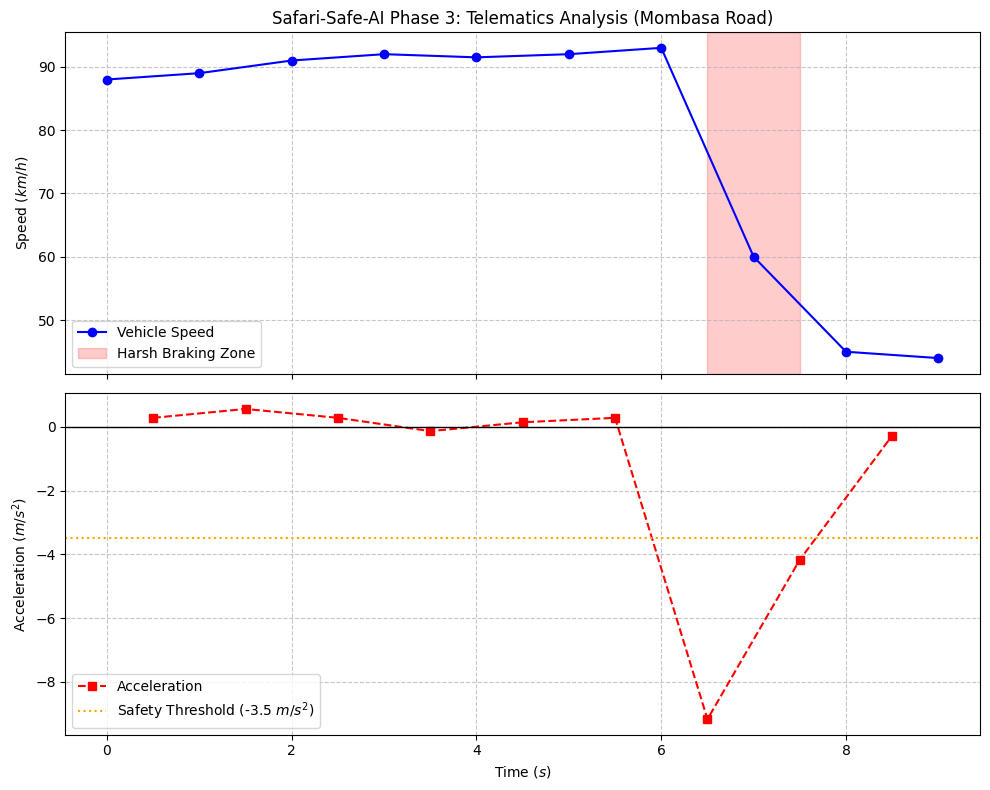

In [8]:
# Data from user
timestamps = np.arange(0, 10, 1.0)
speeds_kmh = np.array([88.0, 89.0, 91.0, 92.0, 91.5, 92.0, 93.0, 60.0, 45.0, 44.0])
speeds_ms = speeds_kmh / 3.6
dt = 1.0
accelerations = np.diff(speeds_ms) / dt

# Time midpoints for acceleration plot
accel_times = timestamps[:-1] + 0.5

# Create plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot 1: Speed
ax1.plot(timestamps, speeds_kmh, marker='o', color='b', linestyle='-', label='Vehicle Speed')
ax1.axvspan(6.5, 7.5, color='red', alpha=0.2, label='Harsh Braking Zone')
ax1.set_ylabel('Speed ($km/h$)')
ax1.set_title('Safari-Safe-AI Phase 3: Telematics Analysis (Mombasa Road)')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# Plot 2: Acceleration
ax2.plot(accel_times, accelerations, marker='s', color='r', linestyle='--', label='Acceleration')
ax2.axhline(0, color='black', linewidth=1)
ax2.axhline(-3.5, color='orange', linestyle=':', label='Safety Threshold (-3.5 $m/s^2$)')
ax2.set_ylabel('Acceleration ($m/s^2$)')
ax2.set_xlabel('Time ($s$)')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.savefig('../figures/safari_safe_telematics.png')

print("Calculated Accelerations (m/s^2):", accelerations)

In [9]:
# Parameters
g = 9.81              # m/s^2
mu_asphalt = 0.7      # Dry asphalt (standard)
mu_gravel = 0.35      # Loose surface/Wet (dangerous)
reaction_time = 1.5   # Nairobi traffic "distracted" estimate (seconds)

# 1. Calculate Maximum Braking Capacity
max_a_asphalt = -mu_asphalt * g
max_a_gravel = -mu_gravel * g

# 2. Identify Skidding Events
skidding_on_asphalt = accelerations < max_a_asphalt
skidding_on_gravel = accelerations < max_a_gravel

# 3. Calculate "Perception-Reaction Distance"
# Distance traveled before the driver even hits the brakes
reaction_distance = speeds_ms[6] * reaction_time 

print(f"Max Deceleration (Asphalt): {max_a_asphalt:.2f} m/s²")
print(f"Max Deceleration (Gravel):  {max_a_gravel:.2f} m/s²")
print("-" * 40)

# Check our t=6->7 event (-9.17 m/s²)
if accelerations[6] < max_a_asphalt:
    print(f"CRITICAL: At t=7, vehicle is SKIDDING even on dry asphalt!")

print(f"Distance covered during reaction time: {reaction_distance:.2f} meters")

Max Deceleration (Asphalt): -6.87 m/s²
Max Deceleration (Gravel):  -3.43 m/s²
----------------------------------------
CRITICAL: At t=7, vehicle is SKIDDING even on dry asphalt!
Distance covered during reaction time: 38.75 meters


In [10]:
# Lead vehicle speed (constant 70 km/h)
lead_speed_ms = 70 / 3.6 

# Initial gap at t=0 (meters)
initial_gap = 50 

# 1. Calculate Relative Speed at each timestep
# If positive, you are gaining on the lead vehicle
rel_speeds = speeds_ms - lead_speed_ms

# 2. Track the Gap over time (Numerical Integration)
# gap_t = gap_{t-1} - (rel_speed * dt)
gaps = [initial_gap]
for rs in rel_speeds:
    new_gap = gaps[-1] - (rs * dt)
    gaps.append(max(0, new_gap)) # Gap can't be less than 0 (collision)

gaps = np.array(gaps[:-1]) # Align with timestamps

# 3. Time-to-Collision (TTC) 
# TTC = Gap / Relative Speed (only when closing the gap)
ttc = np.where(rel_speeds > 0, gaps / rel_speeds, np.inf)

print("="*55)
print("PHASE 3 REFINEMENT: Collision Awareness")
print("="*55)
for i, t in enumerate(ttc):
    status = "⚠️ WARNING" if t < 3.0 else "Safe"
    print(f"t={i}: Gap={gaps[i]:.1f}m | TTC={t:.2f}s | {status}")

PHASE 3 REFINEMENT: Collision Awareness
t=0: Gap=50.0m | TTC=10.00s | Safe
t=1: Gap=45.0m | TTC=8.53s | Safe
t=2: Gap=39.7m | TTC=6.81s | Safe
t=3: Gap=33.9m | TTC=5.55s | Safe
t=4: Gap=27.8m | TTC=4.65s | Safe
t=5: Gap=21.8m | TTC=3.57s | Safe
t=6: Gap=15.7m | TTC=2.46s | ⚠️ WARNING
t=7: Gap=9.3m | TTC=infs | Safe
t=8: Gap=12.1m | TTC=infs | Safe
t=9: Gap=19.0m | TTC=infs | Safe


In [11]:
print("="*55)
print("PHASE 3 Acceleration Analysis with Surface Friction")
print("="*55)


speeds_kmh = np.array([88, 89, 91, 92, 91.5, 92, 93, 60, 45, 44])
speeds_ms  = speeds_kmh / 3.6
dt = 1.0
accelerations = np.diff(speeds_ms) / dt

print("STEP 1 — F=ma: Accelerations m/s²")
print("="*55)
for i, a in enumerate(accelerations):
    flag = " 🚨 \u26A0\ufe0f <- DANGEROUS" if abs(a) > 3.5 else ""
    print(f"  t={i}->{i+1}: {a:+.3f} m/s^2{flag}")

print(f"\nMost dangerous moment: t={np.argmin(accelerations)}")
print(f"Peak deceleration: {accelerations.min():.3f} m/s^2")

PHASE 3 Acceleration Analysis with Surface Friction
STEP 1 — F=ma: Accelerations m/s²
  t=0->1: +0.278 m/s^2
  t=1->2: +0.556 m/s^2
  t=2->3: +0.278 m/s^2
  t=3->4: -0.139 m/s^2
  t=4->5: +0.139 m/s^2
  t=5->6: +0.278 m/s^2
  t=6->7: -9.167 m/s^2 🚨 ⚠️ <- DANGEROUS
  t=7->8: -4.167 m/s^2 🚨 ⚠️ <- DANGEROUS
  t=8->9: -0.278 m/s^2

Most dangerous moment: t=6
Peak deceleration: -9.167 m/s^2


In [12]:
# ============================================
# STEP 2 — SELF-ATTENTION SCORES
# The F=ma to Self-Attention Bridge
# ============================================

# Your acceleration sequence — from Step 1
# This is your "token sequence" in Transformer language
accels = np.array([0.278, 0.556, 0.278, -0.139, 
                   0.139, 0.278, -9.167, -4.167, -0.278])

# ============================================
# In F=ma — force weights acceleration by mass
# F = m × a
# Larger acceleration = larger force = more important

# In Self-Attention — relevance weights each timestep
# Attention(Q,K,V) = softmax(QK^T / sqrt(d)) × V
# Larger dot product = more relevant = more attention

# The bridge:
# F=ma asks: "how much force is happening?"
# Attention asks: "how relevant is this timestep?"
# Both are dynamic weighting systems.
# ============================================

# STEP 2a — Raw attention scores
# How much should each timestep "attend" to itself?
# Use absolute acceleration as proxy for importance
raw_scores = np.abs(accels)

print("STEP 2a — Raw importance scores (|acceleration|):")
print("="*55)
for i, s in enumerate(raw_scores):
    bar = '█' * int(s * 2)
    print(f"  t={i}: {s:+.3f} m/s² | {bar}")

# STEP 2b — Softmax — normalize to attention weights
# Same as distributing a unit load across supports
def softmax(x):
    e_x = np.exp(x - np.max(x))  # stability trick
    return e_x / e_x.sum()

attention_weights = softmax(raw_scores)

print("\nSTEP 2b — Attention weights after softmax:")
print("="*55)
for i, w in enumerate(attention_weights):
    bar = '█' * int(w * 100)
    dangerous = " <- MODEL FOCUSED HERE" if w > 0.3 else ""
    print(f"  t={i}: {w:.4f} | {bar}{dangerous}")

print(f"\nSum of weights: {attention_weights.sum():.4f} (always 1.0)")
print(f"Most attended timestep: t={np.argmax(attention_weights)}")

STEP 2a — Raw importance scores (|acceleration|):
  t=0: +0.278 m/s² | 
  t=1: +0.556 m/s² | █
  t=2: +0.278 m/s² | 
  t=3: +0.139 m/s² | 
  t=4: +0.139 m/s² | 
  t=5: +0.278 m/s² | 
  t=6: +9.167 m/s² | ██████████████████
  t=7: +4.167 m/s² | ████████
  t=8: +0.278 m/s² | 

STEP 2b — Attention weights after softmax:
  t=0: 0.0001 | 
  t=1: 0.0002 | 
  t=2: 0.0001 | 
  t=3: 0.0001 | 
  t=4: 0.0001 | 
  t=5: 0.0001 | 
  t=6: 0.9923 | ███████████████████████████████████████████████████████████████████████████████████████████████████ <- MODEL FOCUSED HERE
  t=7: 0.0067 | 
  t=8: 0.0001 | 

Sum of weights: 1.0000 (always 1.0)
Most attended timestep: t=6


In [13]:
def matrix_multiply(A, B):
    """
    Multiplies two matrices from scratch.
    No numpy.dot() — pure Python loops.
    
    Conformability rule: A columns must equal B rows
    A is m×n, B is n×p, result C is m×p
    
    C[i][j] = sum(A[i][k] * B[k][j]) for k in range(n)
    """
    # Step 1 — Get dimensions
    m = len(A)      # rows in A
    n = len(A[0])   # cols in A = rows in B
    p = len(B[0])   # cols in B

    # Step 2 — Check conformability
    if len(B) != n:
        raise ValueError(
            f"Cannot multiply: A has {n} columns "
            f"but B has {len(B)} rows"
        )

    # Step 3 — Initialize result matrix with zeros
    # C is m × p
    C = [[0.0 for _ in range(p)] for _ in range(m)]

    # Step 4 — Triple loop — the heart of matrix multiplication
    for i in range(m):        # each row of A
        for j in range(p):    # each column of B
            for k in range(n):  # dot product
                C[i][j] += A[i][k] * B[k][j]

    return C


# ============================================
# TEST — Your sensor vectors as matrices
# ============================================

# Query matrix Q — what each timestep is looking for
Q = [
    [0.278,  0.1],   # t=0
    [0.556,  0.2],   # t=1
    [0.278,  0.1],   # t=2
    [9.167,  0.9],   # t=6 dangerous
]

# Key matrix K^T — transposed keys
# Each column = one timestep's key
KT = [
    [0.278, 0.556, 0.278, 9.167],
    [0.1,   0.2,   0.1,   0.9  ],
]

# Multiply Q × K^T — raw attention scores
scores = matrix_multiply(Q, KT)

print("Q × K^T — Raw Attention Scores:")
print("="*55)
print(f"{'':12}", end="")
for j in range(len(KT[0])):
    print(f"  t={j:<6}", end="")
print()
print("-"*55)
for i, row in enumerate(scores):
    label = f"t={i} Query:"
    print(f"{label:<12}", end="")
    for s in row:
        print(f"  {s:<8.3f}", end="")
    print()

# Verify with numpy
print("\nNumPy verification:")
Q_np  = np.array(Q)
KT_np = np.array(KT)
np_result = Q_np @ KT_np
print(np_result.round(3))

print("\nMatch:", np.allclose(scores, np_result))

Q × K^T — Raw Attention Scores:
              t=0       t=1       t=2       t=3     
-------------------------------------------------------
t=0 Query:    0.087     0.175     0.087     2.638   
t=1 Query:    0.175     0.349     0.175     5.277   
t=2 Query:    0.087     0.175     0.087     2.638   
t=3 Query:    2.638     5.277     2.638     84.844  

NumPy verification:
[[ 0.087  0.175  0.087  2.638]
 [ 0.175  0.349  0.175  5.277]
 [ 0.087  0.175  0.087  2.638]
 [ 2.638  5.277  2.638 84.844]]

Match: True


In [16]:
# ============================================
# STEP 2 — SELF-ATTENTION SCORES
# The F=ma to Self-Attention Bridge
# ============================================

# Your acceleration sequence — from Step 1
# This is your "token sequence" in Transformer language
accels = np.array([0.278, 0.556, 0.278, -0.139, 
                   0.139, 0.278, -9.167, -4.167, -0.278])

# ============================================
# In F=ma — force weights acceleration by mass
# F = m × a
# Larger acceleration = larger force = more important

# In Self-Attention — relevance weights each timestep
# Attention(Q,K,V) = softmax(QK^T / sqrt(d)) × V
# Larger dot product = more relevant = more attention

# The bridge:
# F=ma asks: "how much force is happening?"
# Attention asks: "how relevant is this timestep?"
# Both are dynamic weighting systems.
# ============================================

# STEP 2a — Raw attention scores
# How much should each timestep "attend" to itself?
# Use absolute acceleration as proxy for importance
raw_scores = np.abs(accels)

print("STEP 2a — Raw importance scores (|acceleration|):")
print("="*55)
for i, s in enumerate(raw_scores):
    bar = '█' * int(s * 2)
    print(f"  t={i}: {s:+.3f} m/s² | {bar}")

# STEP 2b — Softmax — normalize to attention weights
# Same as distributing a unit load across supports
def softmax(x):
    e_x = np.exp(x - np.max(x))  # stability trick
    return e_x / e_x.sum()

attention_weights = softmax(raw_scores)

print("\nSTEP 2b — Attention weights after softmax:")
print("="*55)
for i, w in enumerate(attention_weights):
    bar = '█' * int(w * 100)
    dangerous = " <- MODEL FOCUSED HERE" if w > 0.3 else ""
    print(f"  t={i}: {w:.4f} | {bar}{dangerous}")

print(f"\nSum of weights: {attention_weights.sum():.4f} (always 1.0)")
print(f"Most attended timestep: t={np.argmax(attention_weights)}")

STEP 2a — Raw importance scores (|acceleration|):
  t=0: +0.278 m/s² | 
  t=1: +0.556 m/s² | █
  t=2: +0.278 m/s² | 
  t=3: +0.139 m/s² | 
  t=4: +0.139 m/s² | 
  t=5: +0.278 m/s² | 
  t=6: +9.167 m/s² | ██████████████████
  t=7: +4.167 m/s² | ████████
  t=8: +0.278 m/s² | 

STEP 2b — Attention weights after softmax:
  t=0: 0.0001 | 
  t=1: 0.0002 | 
  t=2: 0.0001 | 
  t=3: 0.0001 | 
  t=4: 0.0001 | 
  t=5: 0.0001 | 
  t=6: 0.9923 | ███████████████████████████████████████████████████████████████████████████████████████████████████ <- MODEL FOCUSED HERE
  t=7: 0.0067 | 
  t=8: 0.0001 | 

Sum of weights: 1.0000 (always 1.0)
Most attended timestep: t=6


In [19]:
# STEP 3 — Softmax — normalize attention scores
import numpy as np
def softmax_2d(X):

    e_x = np.exp(X - np.max(X, axis=1, keepdims=True))
    return e_x / e_x.sum(axis=1, keepdims=True)

attention_weights = softmax_2d(np_result)

print("\nAttention Weights after Softmax:")
print("="*55)
print(f"{'':10}", end="")
for i in range(len(attention_weights)):
    print(f"{'t='+str(i):>10}", end="")
print()
print("-"*55)
for i, row in enumerate(attention_weights):
    print(f"t={i} Query:", end="")
    for w in row:
        bar = "█" * int(w * 20)
        print(f"{w:>10.4f}", end="")
    print()

print(f"\nMost attended timestep: t={np.argmax(attention_weights.sum(axis=0))}")
print(f"Peak attention weight: {attention_weights.max():.4f}")


Attention Weights after Softmax:
                 t=0       t=1       t=2       t=3
-------------------------------------------------------
t=0 Query:    0.0628    0.0686    0.0628    0.8057
t=1 Query:    0.0060    0.0071    0.0060    0.9810
t=2 Query:    0.0628    0.0686    0.0628    0.8057
t=3 Query:    0.0000    0.0000    0.0000    1.0000

Most attended timestep: t=3
Peak attention weight: 1.0000


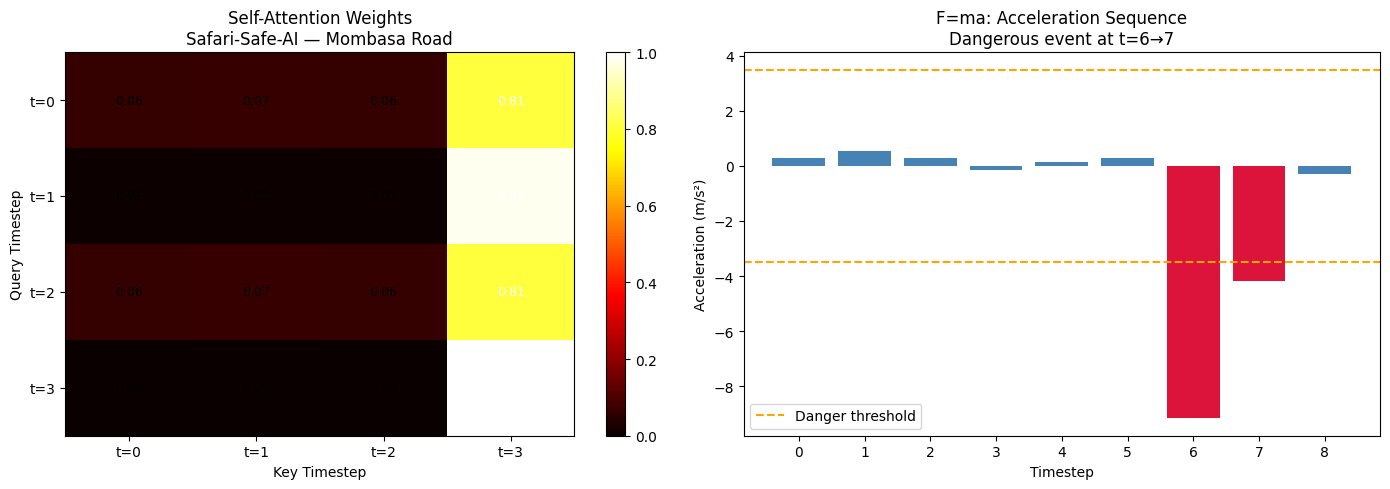

Bridge visualization saved.


In [20]:
# The conference heatmap — attention weights
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Attention heatmap
im = axes[0].imshow(attention_weights, 
                     cmap='hot', 
                     aspect='auto')
axes[0].set_xlabel('Key Timestep')
axes[0].set_ylabel('Query Timestep')
axes[0].set_title('Self-Attention Weights\nSafari-Safe-AI — Mombasa Road')
axes[0].set_xticks(range(4))
axes[0].set_yticks(range(4))
axes[0].set_xticklabels([f't={i}' for i in range(4)])
axes[0].set_yticklabels([f't={i}' for i in range(4)])
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, f'{attention_weights[i,j]:.2f}',
                    ha='center', va='center', 
                    color='white' if attention_weights[i,j] > 0.5 else 'black',
                    fontsize=9)
plt.colorbar(im, ax=axes[0])

# Plot 2 — Acceleration sequence
colors = ['crimson' if abs(a) > 3.5 else 'steelblue' 
          for a in accels]
axes[1].bar(range(len(accels)), accels, color=colors)
axes[1].axhline(y=-3.5, color='orange', 
                linestyle='--', label='Danger threshold')
axes[1].axhline(y=3.5, color='orange', linestyle='--')
axes[1].set_xlabel('Timestep')
axes[1].set_ylabel('Acceleration (m/s²)')
axes[1].set_title('F=ma: Acceleration Sequence\nDangerous event at t=6→7')
axes[1].set_xticks(range(len(accels)))
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/phase3_attention_bridge.png')
plt.show()

print("Bridge visualization saved.")